# Forecast Using the Chronos Family

## Import libraries

In [1]:
import pandas as pd

from foundationforecast import FoundationForecast

/Users/azul/projects/foundationforecast/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:datasets:JAX version 0.7.1 available.



## Load the dataset 

The DataFrame must include at least the following columns:
- unique_id: Unique identifier for each time series (string)
- ds: Date column (datetime format)
- y: Target variable for forecasting (float format)

The pandas frequency will be inferred from the ds column, if not provided.
If the seasonality is not provided, it will be inferred based on the frequency. 
If the horizon is not set, it will default to 2 times the inferred seasonality.

In [2]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()

,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Plot the data

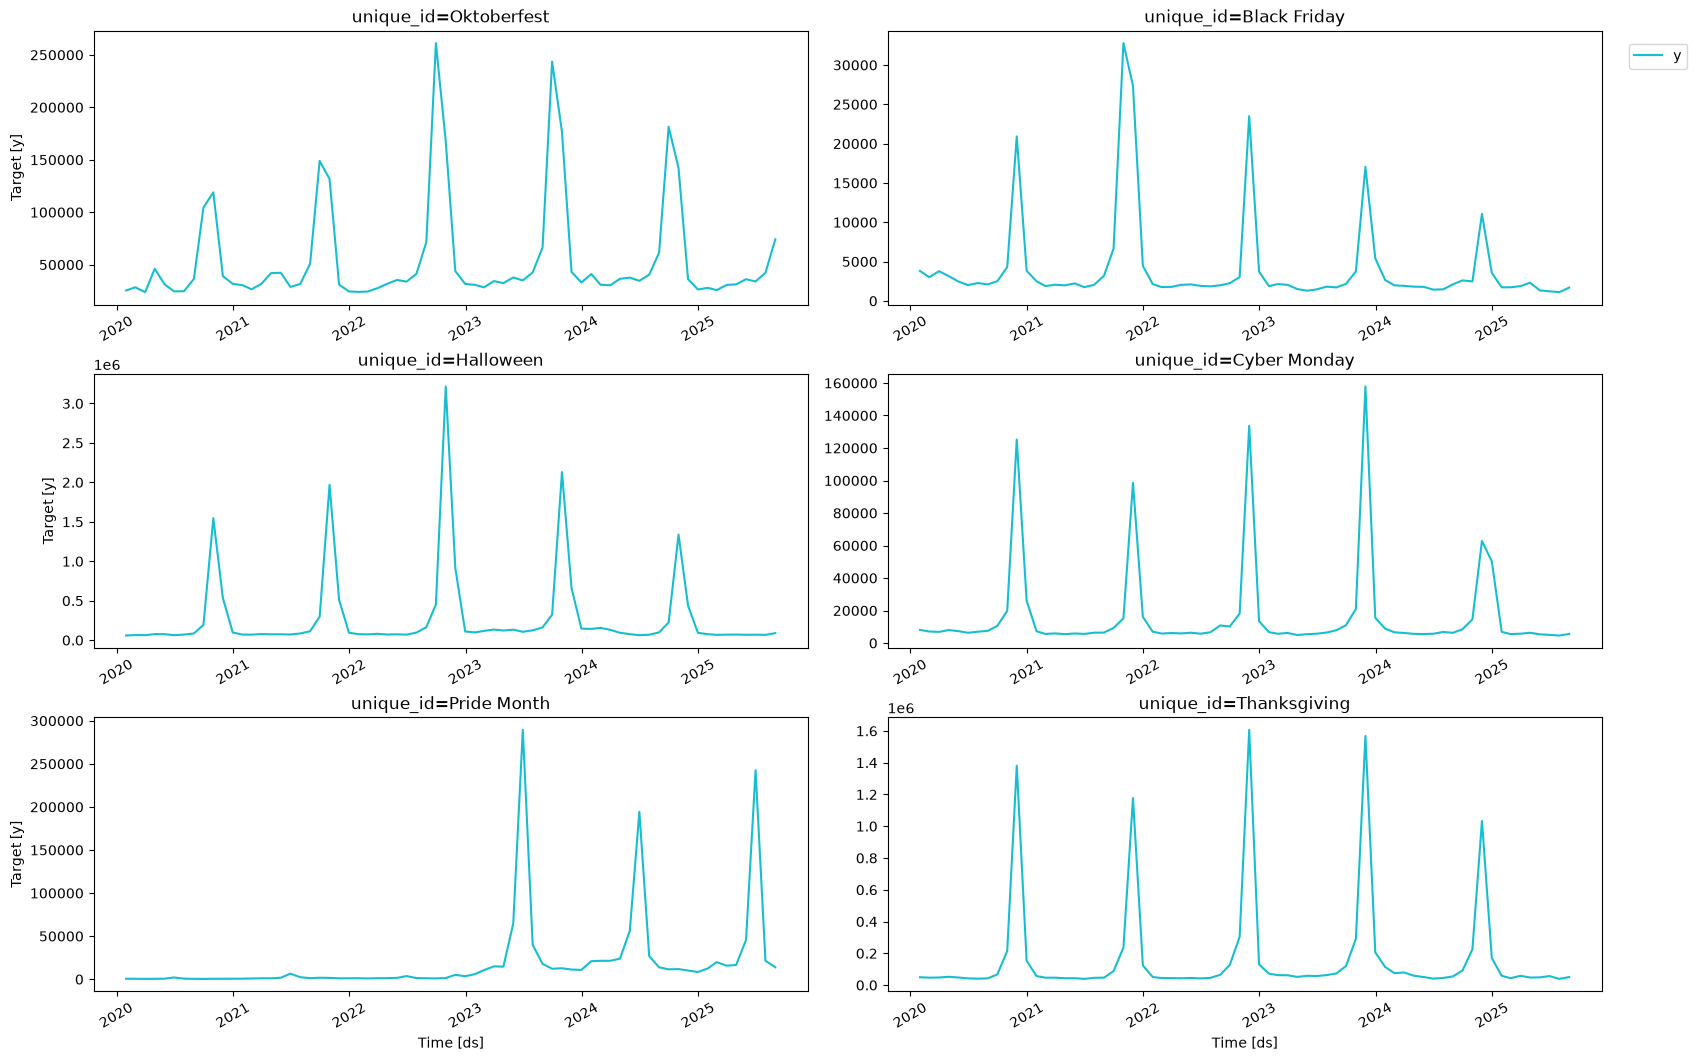

In [3]:
FoundationForecast.plot(df)

## Import the Chronos class 

In [4]:
from foundationforecast.models import Chronos



## Create a FoundationForecast


In [5]:
chronos_av_models = [
    "amazon/chronos-2",
    "amazon/chronos-bolt-tiny",
    "amazon/chronos-bolt-mini",
    "amazon/chronos-bolt-small",
    "amazon/chronos-bolt-base",
    "amazon/chronos-t5-tiny",
    "amazon/chronos-t5-mini",
    "amazon/chronos-t5-small",
    "amazon/chronos-t5-base",
    "amazon/chronos-t5-large",
]
chronos_models = [Chronos(repo_id=model, alias=model) for model in chronos_av_models]

ff = FoundationForecast(models=chronos_models)


## Generate forecast 

You can optionally specify the following parameters:
- freq: The frequency of your data (e.g., 'D' for daily, 'M' for monthly)
- h: The forecast horizon, which is the number of periods to predict
- seasonality: The seasonal period of your data, which can be inferred if not provided


In [6]:
level = [20, 40, 60, 80]
cv_df = ff.cross_validation(df=df, h=12, level=level)

0it [00:00, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
100%|██████████| 1/1 [00:01<00:00,  1.35s/it]
1it [00:02,  2.02s/it]
100%|██████████| 1/1 [00:00<00:00, 12.61it/s]
1it [00:00,  1.82it/s]
100%|██████████| 1/1 [00:00<00:00, 49.93it/s]
1it [00:00,  2.01it/s]
100%|██████████| 1/1 [00:00<00:00,  2.23it/s]
1it [00:00,  1.06it/s]
100%|██████████| 1/1 [00:01<00:00,  1.78s/it]
1it [00:34, 34.52s/it]
100%|██████████| 1/1 [00:00<00:00,  3.22it/s]
1it [00:00,  1.04it/s]
100%|██████████| 1/1 [00:00<00:00,  1.71it/s]
1it [00:01,  1.34s/it]
100%|██████████| 1/1 [00:00<00:00,  1.33it/s]
1it [00:14, 14.71s/it]
100%|██████████| 1/1 [00:04<00:00,  4.80s/it]
1it [00:33, 33.36s/it]
100%|██████████| 1/1 [00:46<00:00, 47.00s/it]
1it [00:47, 47.67s/it]


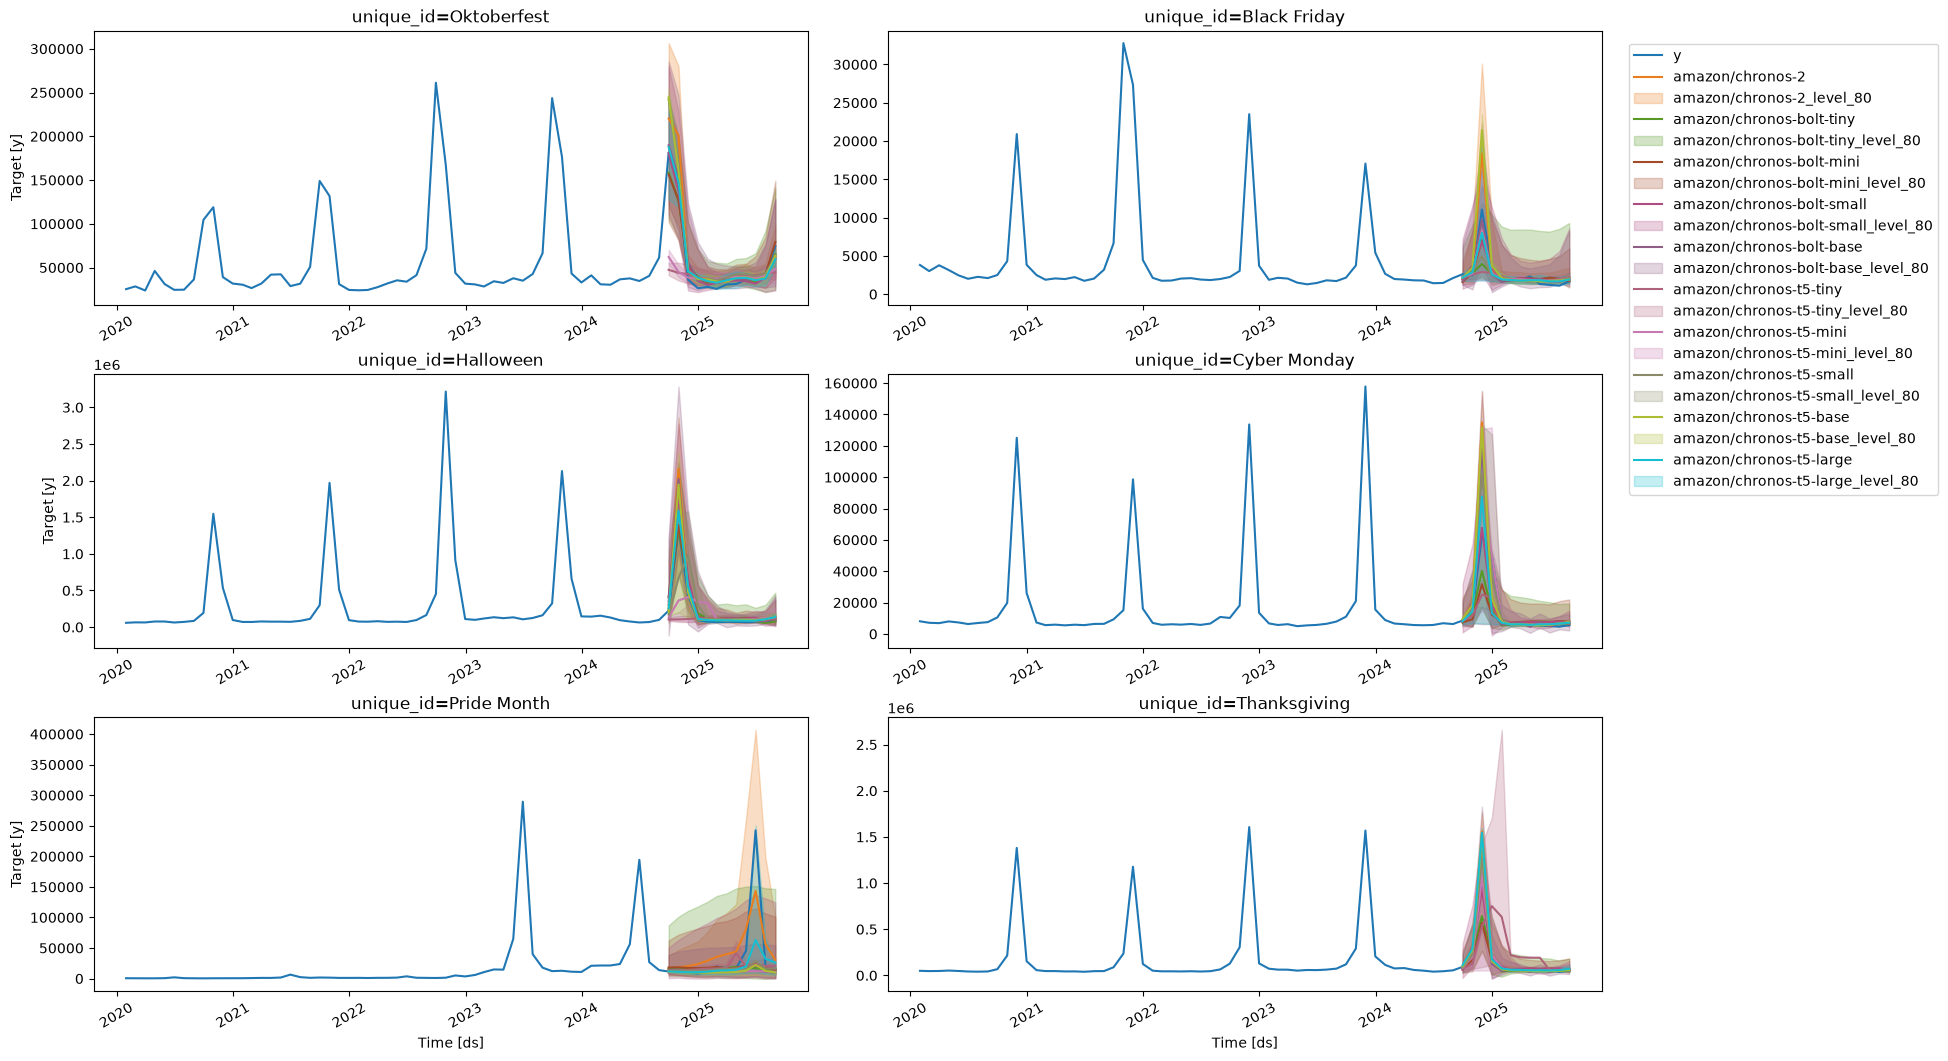

In [7]:
ff.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[80])

In [8]:
cv_df.head()

,unique_id,ds,cutoff,y,amazon/chronos-2,amazon/chronos-2-lo-20,amazon/chronos-2-hi-20,amazon/chronos-2-lo-40,amazon/chronos-2-hi-40,amazon/chronos-2-lo-60,...,amazon/chronos-t5-base-hi-80,amazon/chronos-t5-large,amazon/chronos-t5-large-lo-20,amazon/chronos-t5-large-hi-20,amazon/chronos-t5-large-lo-40,amazon/chronos-t5-large-hi-40,amazon/chronos-t5-large-lo-60,amazon/chronos-t5-large-hi-60,amazon/chronos-t5-large-lo-80,amazon/chronos-t5-large-hi-80
0,Black Friday,2024-09-30,2024-08-31,2607,2095.000244,1996.537354,2180.333496,1889.299316,2296.193848,1789.088623,...,2490.813965,2164.016357,1918.511963,2256.690186,1843.722534,2370.500488,1788.443359,2503.820557,1752.674438,2705.427002
1,Black Friday,2024-10-31,2024-08-31,2470,2686.514648,2313.483398,3336.229492,2049.762939,4364.782227,1866.728271,...,3967.092529,2864.760986,2731.440674,2998.081299,2568.854736,3290.735596,2165.642334,3615.907227,1690.891968,3814.261719
2,Black Friday,2024-11-30,2024-08-31,11058,18391.712891,15877.369141,20407.902344,12313.849609,22806.998047,9150.777344,...,23545.669922,8021.981445,2516.827393,3167.170654,2146.132080,8704.843750,2087.601318,20615.873047,1830.715698,21093.876953
3,Black Friday,2024-12-31,2024-08-31,3548,3263.993164,2747.130127,4157.942871,2353.216553,5379.583008,1998.089844,...,4207.719238,2583.487793,2048.580566,2737.944336,2006.308228,3072.870850,1716.905640,3414.300781,1677.885132,3817.513428
4,Black Friday,2025-01-31,2024-08-31,1724,1994.930420,1902.395020,2072.617676,1800.034180,2184.016113,1696.256836,...,2763.957764,1941.274048,1794.946777,1925.015381,1746.171021,2058.335693,1716.905640,2198.159424,1557.571655,2445.289795


## Evaluation

In [9]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps

In [10]:
eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
eval_df.groupby("metric").mean(numeric_only=True).T.sort_values(by="scaled_crps").round(
    3
)

metric,mase,scaled_crps
amazon/chronos-t5-large,1.093,0.298
amazon/chronos-bolt-small,0.995,0.309
amazon/chronos-bolt-mini,1.277,0.330
amazon/chronos-bolt-tiny,1.146,0.335
amazon/chronos-bolt-base,1.338,0.351
amazon/chronos-2,1.627,0.359
amazon/chronos-t5-small,1.231,0.361
amazon/chronos-t5-base,1.434,0.400
amazon/chronos-t5-mini,1.225,0.409
amazon/chronos-t5-tiny,2.549,0.525
